## 1. 环境准备与依赖安装

In [12]:
!pip install transformers torch tqdm scikit-learn matplotlib seaborn datasets aiomysql cryptography -q

^C


## 2. 导入必要的库

In [1]:
import sys
import os
sys.path.append('..')


import asyncio
from datetime import datetime
from typing import List, Dict, Tuple

import aiomysql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
import torch.optim as optim
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from config import db_config

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)
import transformers
print(f"Transformers 版本: {transformers.__version__}")
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA是否可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA版本: {torch.version.cuda}")
    print(f"GPU设备: {torch.cuda.get_device_name(0)}")
    print(f"GPU内存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Transformers 版本: 4.47.1
PyTorch版本: 2.5.1+cu121
CUDA是否可用: True
CUDA版本: 12.1
GPU设备: NVIDIA GeForce RTX 4060 Laptop GPU
GPU内存: 8.00 GB


## 3. 配置参数（必做：使用指定模型和超参数）

In [2]:
# ============ 必做配置 ============
MODEL_NAME = "hfl/chinese-roberta-wwm-ext"  # 第一步：指定模型
LEARNING_RATE = 2e-5  # 第二步：学习率
NUM_EPOCHS = 3  # 第二步：训练轮数
# ==================================

# 其他配置
TEST_DB_NAME = "nlp_test_dataset"
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_LENGTH = 512
BATCH_SIZE = 16
WARMUP_STEPS = 100
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0

# 数据划分比例
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# 模型保存路径
MODEL_SAVE_DIR = "./models/roberta_finetuned"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

print("=" * 60)
print("训练配置".center(60))
print("=" * 60)
print(f"模型: {MODEL_NAME}")
print(f"学习率: {LEARNING_RATE}")
print(f"训练轮数: {NUM_EPOCHS}")
print(f"设备: {DEVICE}")
print(f"批大小: {BATCH_SIZE}")
print(f"最大长度: {MAX_LENGTH}")
print(f"预热步数: {WARMUP_STEPS}")
print(f"权重衰减: {WEIGHT_DECAY}")
print(f"梯度裁剪: {MAX_GRAD_NORM}")
print(f"数据划分: Train {TRAIN_RATIO*100:.0f}% | Val {VAL_RATIO*100:.0f}% | Test {TEST_RATIO*100:.0f}%")
print("=" * 60)

                            训练配置                            
模型: hfl/chinese-roberta-wwm-ext
学习率: 2e-05
训练轮数: 3
设备: cuda
批大小: 16
最大长度: 512
预热步数: 100
权重衰减: 0.01
梯度裁剪: 1.0
数据划分: Train 70% | Val 15% | Test 15%


## 4. 加载数据

In [3]:
async def get_mysql_connection():
    """创建MySQL连接"""
    return await aiomysql.connect(
        host=db_config.MYSQL_DB_HOST,
        port=db_config.MYSQL_DB_PORT,
        user=db_config.MYSQL_DB_USER,
        password=db_config.MYSQL_DB_PWD,
        db=TEST_DB_NAME,
        charset='utf8mb4',
        autocommit=True
    )

async def load_annotated_data():
    """加载已标注的测试数据"""
    conn = await get_mysql_connection()
    try:
        async with conn.cursor(aiomysql.DictCursor) as cursor:
            # 加载笔记数据
            await cursor.execute("""
                SELECT id, platform, title, content, manual_sentiment_label
                FROM test_notes 
                WHERE is_annotated = TRUE
                ORDER BY id
            """)
            notes = await cursor.fetchall()
            
            # 加载评论数据
            await cursor.execute("""
                SELECT id, platform, content, manual_sentiment_label
                FROM test_comments 
                WHERE is_annotated = TRUE
                ORDER BY id
            """)
            comments = await cursor.fetchall()
            
            return notes, comments
    finally:
        conn.close()

# 加载数据
notes_data, comments_data = await load_annotated_data()

print(f"已加载笔记数据: {len(notes_data)} 条")
print(f"已加载评论数据: {len(comments_data)} 条")
print(f"总计: {len(notes_data) + len(comments_data)} 条")

已加载笔记数据: 60 条
已加载评论数据: 300 条
总计: 360 条


## 5. 数据预处理

In [4]:
# 转换为DataFrame
df_notes = pd.DataFrame(notes_data)
df_comments = pd.DataFrame(comments_data)

# 合并标题和内容
if len(df_notes) > 0:
    df_notes['text'] = df_notes['title'].fillna('') + ' ' + df_notes['content'].fillna('')
    df_notes = df_notes[['text', 'manual_sentiment_label']].rename(
        columns={'manual_sentiment_label': 'label'}
    )

if len(df_comments) > 0:
    df_comments['text'] = df_comments['content'].fillna('')
    df_comments = df_comments[['text', 'manual_sentiment_label']].rename(
        columns={'manual_sentiment_label': 'label'}
    )

# 合并所有数据
df_all = pd.concat([df_notes, df_comments], ignore_index=True)

# 标签映射
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df_all['label_id'] = df_all['label'].map(label_map)

print(f"\n数据统计:")
print(f"总样本数: {len(df_all)}")
print(f"\n标签分布:")
print(df_all['label'].value_counts())
print(f"\n文本长度统计:")
df_all['text_length'] = df_all['text'].str.len()
print(df_all['text_length'].describe())

# 显示样本
print(f"\n样本预览:")
display(df_all.head(5))


数据统计:
总样本数: 360

标签分布:
label
negative    143
positive    130
neutral      87
Name: count, dtype: int64

文本长度统计:
count     360.000000
mean      133.858333
std       479.134589
min         0.000000
25%        11.000000
50%        23.000000
75%        56.250000
max      5061.000000
Name: text_length, dtype: float64

样本预览:


,text,label,label_id,text_length
0,安卓开发现状怎么样？ 2025.09.23，二更一下。端侧AI模型部署，还是有市场的，工资也...,positive,2,876
1,安卓到底是不是100%开源？ AOSP是100%开源的，这个没什么好质疑的。只不过Googl...,negative,0,969
2,2026Android开发现在还能入行吗? 单就在北京安卓而言，我的情况是Android底层...,positive,2,1191
3,台海局势越来越紧张，您认为会发生战争吗？ 跟着外汇储备来看，目前中国的外汇总值超过3兆美元，...,positive,2,386
4,你能列举一些iphone的优缺点吗？ 1.不能截长图，截长图需要微信进行合并拼接，或者第三方...,negative,0,156


## 6. 创建自定义Dataset类

In [5]:
class SentimentDataset(Dataset):
    """情感分析数据集"""
    
    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_length: int = 512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # 分词
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("✓ Dataset类定义完成")

✓ Dataset类定义完成


## 7. 加载分词器和模型

In [6]:
print(f"正在加载模型: {MODEL_NAME}...")
print("首次运行会自动下载模型，请耐心等待...\n")

# 加载分词器
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("✓ 分词器加载成功")

# 加载模型
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3  # 三分类：negative, neutral, positive
)
model.to(DEVICE)
print(f"✓ 模型加载成功，已移至 {DEVICE}")

# 模型参数统计
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n模型参数量: {total_params:,}")
print(f"可训练参数: {trainable_params:,}")

正在加载模型: hfl/chinese-roberta-wwm-ext...
首次运行会自动下载模型，请耐心等待...

✓ 分词器加载成功


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at hfl/chinese-roberta-wwm-ext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ 模型加载成功，已移至 cuda

模型参数量: 102,269,955
可训练参数: 102,269,955


## 8. 划分数据集

In [7]:
# 准备数据
texts = df_all['text'].tolist()
labels = df_all['label_id'].tolist()

# 创建完整数据集
full_dataset = SentimentDataset(texts, labels, tokenizer, MAX_LENGTH)

# 计算划分大小
total_size = len(full_dataset)
train_size = int(total_size * TRAIN_RATIO)
val_size = int(total_size * VAL_RATIO)
test_size = total_size - train_size - val_size

# 随机划分
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"数据集划分:")
print(f"训练集: {len(train_dataset)} 样本 ({len(train_dataset)/total_size*100:.1f}%)")
print(f"验证集: {len(val_dataset)} 样本 ({len(val_dataset)/total_size*100:.1f}%)")
print(f"测试集: {len(test_dataset)} 样本 ({len(test_dataset)/total_size*100:.1f}%)")

# 创建DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"\nDataLoader创建完成:")
print(f"训练批次: {len(train_loader)}")
print(f"验证批次: {len(val_loader)}")
print(f"测试批次: {len(test_loader)}")

数据集划分:
训练集: 251 样本 (69.7%)
验证集: 54 样本 (15.0%)
测试集: 55 样本 (15.3%)

DataLoader创建完成:
训练批次: 16
验证批次: 4
测试批次: 4


## 9. 设置优化器和学习率调度器

In [8]:
# 优化器
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# 学习率调度器（线性预热+线性衰减）
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"优化器配置完成:")
print(f"学习率: {LEARNING_RATE}")
print(f"权重衰减: {WEIGHT_DECAY}")
print(f"总训练步数: {total_steps}")
print(f"预热步数: {WARMUP_STEPS}")

优化器配置完成:
学习率: 2e-05
权重衰减: 0.01
总训练步数: 48
预热步数: 100


## 10. 定义训练和评估函数

In [9]:
def train_epoch(model, dataloader, optimizer, scheduler, device):
    """训练一个epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    
    for batch in progress_bar:
        # 移动到设备
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # 前向传播
        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        # 反向传播
        loss.backward()
        
        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        
        optimizer.step()
        scheduler.step()
        
        # 统计
        total_loss += loss.item()
        predictions = torch.argmax(logits, dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        
        # 更新进度条
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{correct/total:.4f}'
        })
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    
    return avg_loss, accuracy


def evaluate(model, dataloader, device):
    """评估模型"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            total_loss += loss.item()
            predictions = torch.argmax(logits, dim=-1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_predictions)
    
    return avg_loss, accuracy, all_predictions, all_labels


print("✓ 训练和评估函数定义完成")

✓ 训练和评估函数定义完成


## 11. 开始训练（3个Epoch）

In [10]:
print("=" * 60)
print("开始训练".center(60))
print("=" * 60)

# 记录训练历史
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0
best_epoch = 0
start_time = datetime.now()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = datetime.now()
    
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 60)
    
    # 训练
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, DEVICE
    )
    
    # 验证
    val_loss, val_acc, _, _ = evaluate(model, val_loader, DEVICE)
    
    # 记录历史
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # 显示结果
    epoch_time = (datetime.now() - epoch_start_time).total_seconds()
    print(f"\n训练损失: {train_loss:.4f} | 训练准确率: {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"验证损失: {val_loss:.4f} | 验证准确率: {val_acc:.4f} ({val_acc*100:.2f}%)")
    print(f"耗时: {epoch_time:.2f}秒")
    
    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        
        save_path = os.path.join(MODEL_SAVE_DIR, "best_model")
        model.save_pretrained(save_path)
        tokenizer.save_pretrained(save_path)
        print(f"✓ 保存最佳模型 (验证准确率: {best_val_acc:.4f})")

total_time = (datetime.now() - start_time).total_seconds()

print("\n" + "=" * 60)
print("训练完成".center(60))
print("=" * 60)
print(f"总耗时: {total_time:.2f}秒 ({total_time/60:.2f}分钟)")
print(f"最佳验证准确率: {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"模型保存路径: {MODEL_SAVE_DIR}/best_model")

                            开始训练                            

Epoch 1/3
------------------------------------------------------------


Training:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]


训练损失: 1.1798 | 训练准确率: 0.3466 (34.66%)
验证损失: 0.9667 | 验证准确率: 0.6111 (61.11%)
耗时: 21.21秒
✓ 保存最佳模型 (验证准确率: 0.6111)

Epoch 2/3
------------------------------------------------------------


Training:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]


训练损失: 1.0822 | 训练准确率: 0.3904 (39.04%)
验证损失: 0.9959 | 验证准确率: 0.5185 (51.85%)
耗时: 17.84秒

Epoch 3/3
------------------------------------------------------------


Training:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]


训练损失: 1.0380 | 训练准确率: 0.4582 (45.82%)
验证损失: 0.9592 | 验证准确率: 0.5556 (55.56%)
耗时: 16.25秒

                            训练完成                            
总耗时: 58.03秒 (0.97分钟)
最佳验证准确率: 0.6111 (Epoch 1)
模型保存路径: ./models/roberta_finetuned/best_model


## 12. 可视化训练过程

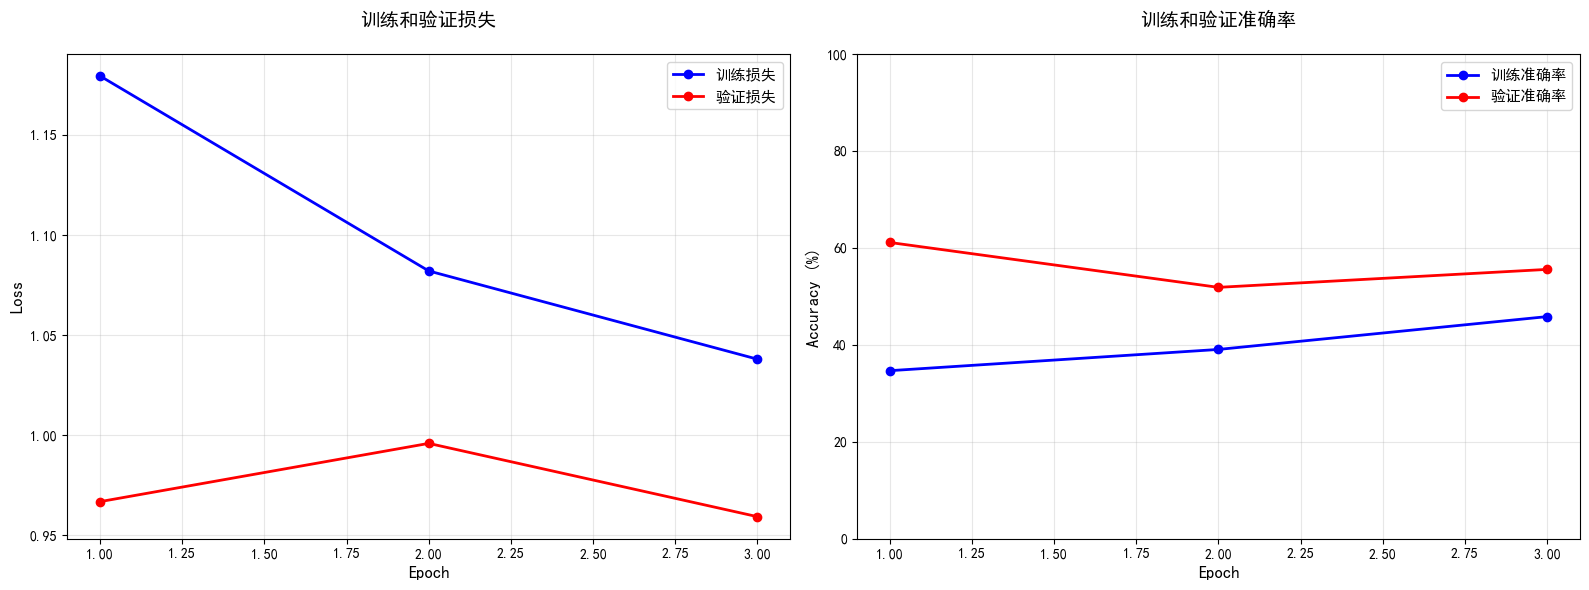

✓ 训练曲线已保存至: ./models/roberta_finetuned/training_curves.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs = range(1, NUM_EPOCHS + 1)

# 损失曲线
ax1.plot(epochs, history['train_loss'], 'b-o', label='训练损失', linewidth=2)
ax1.plot(epochs, history['val_loss'], 'r-o', label='验证损失', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('训练和验证损失', fontsize=14, pad=20)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# 准确率曲线
ax2.plot(epochs, [x*100 for x in history['train_acc']], 'b-o', label='训练准确率', linewidth=2)
ax2.plot(epochs, [x*100 for x in history['val_acc']], 'r-o', label='验证准确率', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('训练和验证准确率', fontsize=14, pad=20)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 100])

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'training_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ 训练曲线已保存至: {MODEL_SAVE_DIR}/training_curves.png")

## 13. 在测试集上评估

In [12]:
print("=" * 60)
print("测试集评估".center(60))
print("=" * 60)

# 加载最佳模型
best_model_path = os.path.join(MODEL_SAVE_DIR, "best_model")
model = AutoModelForSequenceClassification.from_pretrained(best_model_path)
model.to(DEVICE)
print(f"✓ 已加载最佳模型")

# 在测试集上评估
test_loss, test_acc, test_predictions, test_labels = evaluate(
    model, test_loader, DEVICE
)

print(f"\n测试集结果:")
print(f"损失: {test_loss:.4f}")
print(f"准确率: {test_acc:.4f} ({test_acc*100:.2f}%)")

# 详细分类报告
print("\n" + "-" * 60)
print("分类报告".center(60))
print("-" * 60)
label_names = ['negative', 'neutral', 'positive']
print(classification_report(
    test_labels,
    test_predictions,
    target_names=label_names,
    digits=4
))

# 计算各类别指标
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_predictions, average=None, zero_division=0
)

metrics_df = pd.DataFrame({
    '类别': label_names,
    '精确率': precision,
    '召回率': recall,
    'F1值': f1,
    '样本数': support
})

print("\n详细指标:")
display(metrics_df)

                           测试集评估                            
✓ 已加载最佳模型


Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]


测试集结果:
损失: 1.0824
准确率: 0.4182 (41.82%)

------------------------------------------------------------
                            分类报告                            
------------------------------------------------------------
              precision    recall  f1-score   support

    negative     0.4182    1.0000    0.5897        23
     neutral     0.0000    0.0000    0.0000        13
    positive     0.0000    0.0000    0.0000        19

    accuracy                         0.4182        55
   macro avg     0.1394    0.3333    0.1966        55
weighted avg     0.1749    0.4182    0.2466        55


详细指标:


f:\CodeSoftware\Anaconda\envs\rtx4060_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\CodeSoftware\Anaconda\envs\rtx4060_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\CodeSoftware\Anaconda\envs\rtx4060_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

,类别,精确率,召回率,F1值,样本数
0,negative,0.418182,1.0,0.589744,23
1,neutral,0.000000,0.0,0.000000,13
2,positive,0.000000,0.0,0.000000,19


## 14. 绘制测试集混淆矩阵

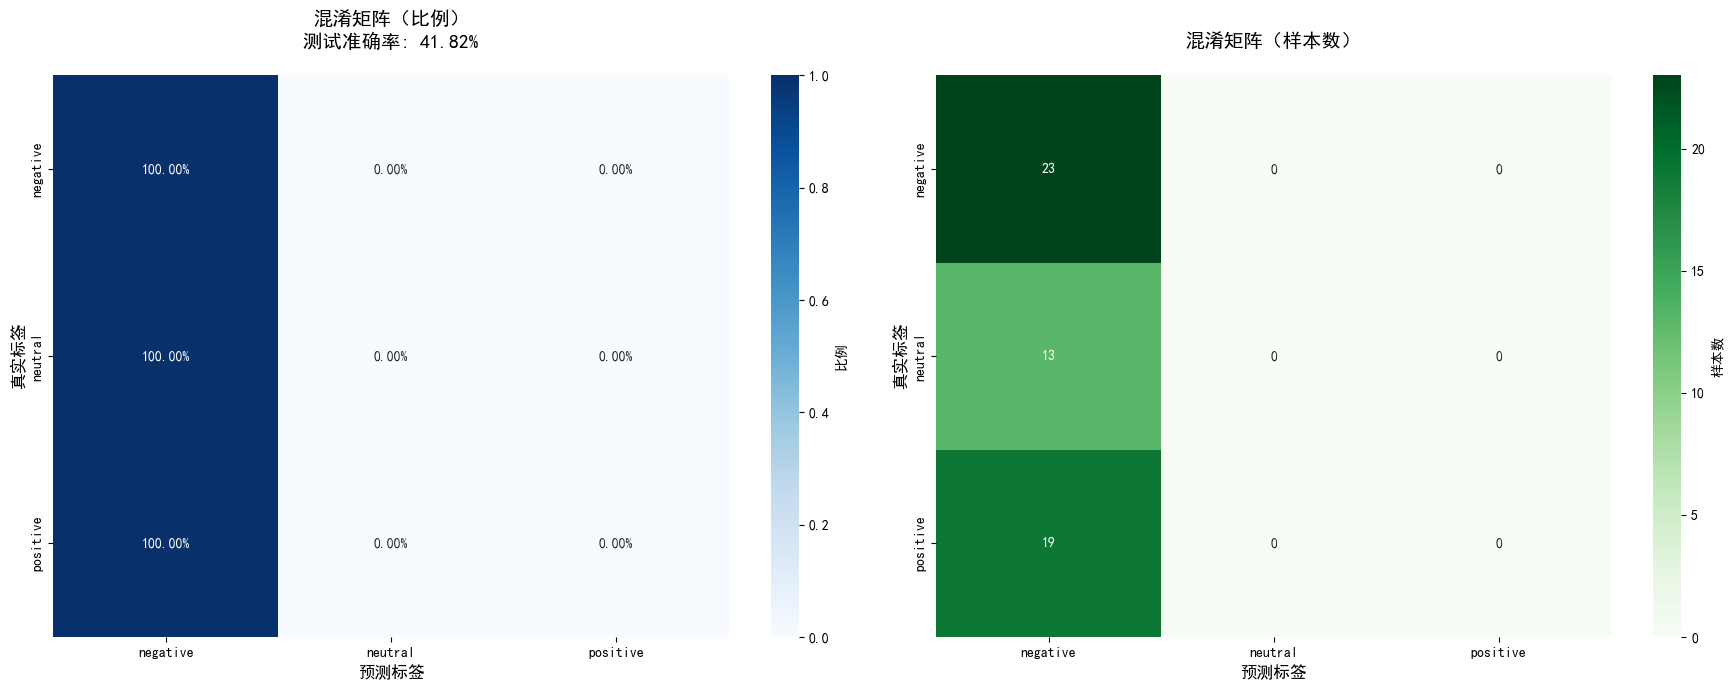

✓ 混淆矩阵已保存至: ./models/roberta_finetuned/confusion_matrix.png


In [13]:
# 计算混淆矩阵
cm = confusion_matrix(test_labels, test_predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 归一化混淆矩阵
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
    cbar_kws={'label': '比例'},
    ax=ax1
)
ax1.set_title(f'混淆矩阵（比例）\n测试准确率: {test_acc:.2%}', fontsize=14, pad=20)
ax1.set_ylabel('真实标签', fontsize=12)
ax1.set_xlabel('预测标签', fontsize=12)

# 实际数量混淆矩阵
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_names,
    yticklabels=label_names,
    cbar_kws={'label': '样本数'},
    ax=ax2
)
ax2.set_title(f'混淆矩阵（样本数）', fontsize=14, pad=20)
ax2.set_ylabel('真实标签', fontsize=12)
ax2.set_xlabel('预测标签', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ 混淆矩阵已保存至: {MODEL_SAVE_DIR}/confusion_matrix.png")

## 15. 对比零样本和微调结果

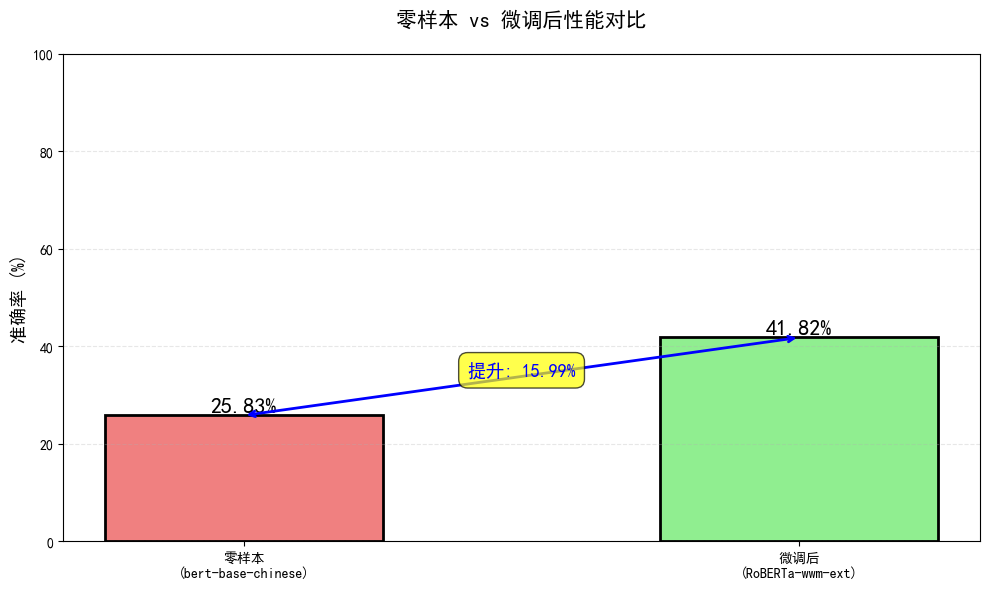


性能对比:
零样本准确率: 25.83%
微调后准确率: 41.82%
绝对提升: 15.99 百分点
相对提升: 61.90%

✓ 对比图已保存至: ./models/roberta_finetuned/comparison.png


In [14]:
# 零样本基线（来自transformer_sentiment_analysis.ipynb的结果）
zero_shot_acc = 0.2583  # 25.83%

# 绘制对比图
fig, ax = plt.subplots(figsize=(10, 6))

methods = ['零样本\n(bert-base-chinese)', '微调后\n(RoBERTa-wwm-ext)']
accuracies = [zero_shot_acc * 100, test_acc * 100]
colors = ['lightcoral', 'lightgreen']

bars = ax.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=2, width=0.5)

# 添加数值标签
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2f}%',
            ha='center', va='bottom', fontsize=16, fontweight='bold')

# 添加改进线
improvement = test_acc - zero_shot_acc
ax.annotate('',
            xy=(1, test_acc * 100),
            xytext=(0, zero_shot_acc * 100),
            arrowprops=dict(arrowstyle='<->', color='blue', lw=2))

ax.text(0.5, (zero_shot_acc + test_acc) * 50,
        f'提升: {improvement*100:.2f}%',
        ha='center', fontsize=13, color='blue', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax.set_ylabel('准确率 (%)', fontsize=13)
ax.set_title('零样本 vs 微调后性能对比', fontsize=15, pad=20, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n性能对比:")
print(f"零样本准确率: {zero_shot_acc*100:.2f}%")
print(f"微调后准确率: {test_acc*100:.2f}%")
print(f"绝对提升: {improvement*100:.2f} 百分点")
print(f"相对提升: {(improvement/zero_shot_acc)*100:.2f}%")
print(f"\n✓ 对比图已保存至: {MODEL_SAVE_DIR}/comparison.png")

## 16. 保存训练结果和配置

In [15]:
import json

# 保存训练配置和结果
results = {
    "model_name": MODEL_NAME,
    "training_config": {
        "learning_rate": LEARNING_RATE,
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "max_length": MAX_LENGTH,
        "warmup_steps": WARMUP_STEPS,
        "weight_decay": WEIGHT_DECAY,
        "max_grad_norm": MAX_GRAD_NORM
    },
    "data_split": {
        "total_samples": len(full_dataset),
        "train_samples": len(train_dataset),
        "val_samples": len(val_dataset),
        "test_samples": len(test_dataset)
    },
    "training_history": history,
    "best_model": {
        "epoch": best_epoch,
        "val_accuracy": float(best_val_acc)
    },
    "test_results": {
        "loss": float(test_loss),
        "accuracy": float(test_acc),
        "precision": precision.tolist(),
        "recall": recall.tolist(),
        "f1_score": f1.tolist(),
        "support": support.tolist()
    },
    "comparison": {
        "zero_shot_accuracy": zero_shot_acc,
        "finetuned_accuracy": float(test_acc),
        "improvement": float(test_acc - zero_shot_acc)
    },
    "training_time": {
        "total_seconds": total_time,
        "total_minutes": total_time / 60
    },
    "timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

# 保存为JSON
results_path = os.path.join(MODEL_SAVE_DIR, 'training_results.json')
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"✓ 训练结果已保存至: {results_path}")

✓ 训练结果已保存至: ./models/roberta_finetuned\training_results.json


## 17. 生成完整训练报告

In [16]:
print("=" * 80)
print("BERT微调训练完整报告".center(80))
print("=" * 80)

print(f"\n【模型信息】")
print(f"  模型: {MODEL_NAME}")
print(f"  参数量: {total_params:,}")
print(f"  设备: {DEVICE}")

print(f"\n【训练配置】")
print(f"  学习率: {LEARNING_RATE}")
print(f"  训练轮数: {NUM_EPOCHS}")
print(f"  批大小: {BATCH_SIZE}")
print(f"  最大长度: {MAX_LENGTH}")
print(f"  预热步数: {WARMUP_STEPS}")
print(f"  权重衰减: {WEIGHT_DECAY}")
print(f"  梯度裁剪: {MAX_GRAD_NORM}")

print(f"\n【数据统计】")
print(f"  总样本数: {len(full_dataset)}")
print(f"  训练集: {len(train_dataset)} ({len(train_dataset)/len(full_dataset)*100:.1f}%)")
print(f"  验证集: {len(val_dataset)} ({len(val_dataset)/len(full_dataset)*100:.1f}%)")
print(f"  测试集: {len(test_dataset)} ({len(test_dataset)/len(full_dataset)*100:.1f}%)")

print(f"\n【训练过程】")
for epoch in range(NUM_EPOCHS):
    print(f"  Epoch {epoch+1}:")
    print(f"    训练损失: {history['train_loss'][epoch]:.4f} | 训练准确率: {history['train_acc'][epoch]:.4f}")
    print(f"    验证损失: {history['val_loss'][epoch]:.4f} | 验证准确率: {history['val_acc'][epoch]:.4f}")

print(f"\n【最佳模型】")
print(f"  最佳Epoch: {best_epoch}")
print(f"  验证准确率: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

print(f"\n【测试集结果】")
print(f"  准确率: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  损失: {test_loss:.4f}")

print(f"\n【各类别性能】")
for i, label in enumerate(label_names):
    print(f"  {label.capitalize():10s}: P={precision[i]:.4f}, R={recall[i]:.4f}, "
          f"F1={f1[i]:.4f}, Support={support[i]}")

print(f"\n【性能对比】")
print(f"  零样本准确率: {zero_shot_acc*100:.2f}%")
print(f"  微调后准确率: {test_acc*100:.2f}%")
print(f"  绝对提升: +{(test_acc - zero_shot_acc)*100:.2f} 百分点")
print(f"  相对提升: +{((test_acc - zero_shot_acc)/zero_shot_acc)*100:.2f}%")

print(f"\n【训练时间】")
print(f"  总耗时: {total_time:.2f}秒 ({total_time/60:.2f}分钟)")
print(f"  平均每轮: {total_time/NUM_EPOCHS:.2f}秒")

print(f"\n【保存文件】")
print(f"  模型: {MODEL_SAVE_DIR}/best_model/")
print(f"  训练曲线: {MODEL_SAVE_DIR}/training_curves.png")
print(f"  混淆矩阵: {MODEL_SAVE_DIR}/confusion_matrix.png")
print(f"  对比图: {MODEL_SAVE_DIR}/comparison.png")
print(f"  结果文件: {MODEL_SAVE_DIR}/training_results.json")

print("\n" + "=" * 80)
print("训练完成！模型已准备就绪。".center(80))
print("=" * 80)

if test_acc >= 0.75:
    print("\n✓ 测试准确率达到预期目标 (≥75%)")
else:
    print(f"\n⚠️ 测试准确率 ({test_acc*100:.2f}%) 未达到75%，建议:")
    print("  - 增加训练数据")
    print("  - 尝试更多epoch")
    print("  - 调整学习率或其他超参数")
    print("  - 检查数据质量和标注一致性")

                                  BERT微调训练完整报告                                  

【模型信息】
  模型: hfl/chinese-roberta-wwm-ext
  参数量: 102,269,955
  设备: cuda

【训练配置】
  学习率: 2e-05
  训练轮数: 3
  批大小: 16
  最大长度: 512
  预热步数: 100
  权重衰减: 0.01
  梯度裁剪: 1.0

【数据统计】
  总样本数: 360
  训练集: 251 (69.7%)
  验证集: 54 (15.0%)
  测试集: 55 (15.3%)

【训练过程】
  Epoch 1:
    训练损失: 1.1798 | 训练准确率: 0.3466
    验证损失: 0.9667 | 验证准确率: 0.6111
  Epoch 2:
    训练损失: 1.0822 | 训练准确率: 0.3904
    验证损失: 0.9959 | 验证准确率: 0.5185
  Epoch 3:
    训练损失: 1.0380 | 训练准确率: 0.4582
    验证损失: 0.9592 | 验证准确率: 0.5556

【最佳模型】
  最佳Epoch: 1
  验证准确率: 0.6111 (61.11%)

【测试集结果】
  准确率: 0.4182 (41.82%)
  损失: 1.0824

【各类别性能】
  Negative  : P=0.4182, R=1.0000, F1=0.5897, Support=23
  Neutral   : P=0.0000, R=0.0000, F1=0.0000, Support=13
  Positive  : P=0.0000, R=0.0000, F1=0.0000, Support=19

【性能对比】
  零样本准确率: 25.83%
  微调后准确率: 41.82%
  绝对提升: +15.99 百分点
  相对提升: +61.90%

【训练时间】
  总耗时: 58.03秒 (0.97分钟)
  平均每轮: 19.34秒

【保存文件】
  模型: ./models/roberta_finetuned/best_model/

## 18. 模型使用示例

In [17]:
def predict_sentiment(text: str, model, tokenizer, device):
    """使用微调后的模型预测情感"""
    model.eval()
    
    # 分词
    inputs = tokenizer(
        text,
        max_length=MAX_LENGTH,
        truncation=True,
        padding=True,
        return_tensors='pt'
    ).to(device)
    
    # 预测
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        predicted_class = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][predicted_class].item()
    
    label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    label = label_map[predicted_class]
    
    return label, confidence, probs[0].cpu().numpy()


# 示例预测
test_texts = [
    "这个产品真的太好用了，强烈推荐！",
    "质量很差，完全不值这个价格。",
    "还可以吧，没什么特别的。"
]

print("\n微调后模型预测示例:")
print("=" * 80)

for text in test_texts:
    label, confidence, probs = predict_sentiment(text, model, tokenizer, DEVICE)
    print(f"\n文本: {text}")
    print(f"预测: {label} (置信度: {confidence:.4f})")
    print(f"概率分布: Negative={probs[0]:.4f}, Neutral={probs[1]:.4f}, Positive={probs[2]:.4f}")
    print("-" * 80)


微调后模型预测示例:

文本: 这个产品真的太好用了，强烈推荐！
预测: negative (置信度: 0.4656)
概率分布: Negative=0.4656, Neutral=0.3249, Positive=0.2094
--------------------------------------------------------------------------------

文本: 质量很差，完全不值这个价格。
预测: negative (置信度: 0.4519)
概率分布: Negative=0.4519, Neutral=0.3070, Positive=0.2411
--------------------------------------------------------------------------------

文本: 还可以吧，没什么特别的。
预测: negative (置信度: 0.4519)
概率分布: Negative=0.4519, Neutral=0.2657, Positive=0.2824
--------------------------------------------------------------------------------
